In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import integrate
import numpy as np
import os
import numpy as np
from scipy.stats import shapiro,mannwhitneyu,levene,pearsonr,spearmanr
from scipy import stats
import statsmodels.api as sm


In [114]:
ls ../EnergyData

EnergyLogger_energy_data.csv  sigless_energy_data.csv
EnergyLogger_power_data.csv   sigless_power_data.csv


## Import Data

In [117]:
#import all the CSV files for External measurements (Chunked Data)

filename_energylogger = '../EnergyData/EnergyLogger_energy_data.csv'
filename_sigless = '../EnergyData/sigless_energy_data.csv'

df_energylogger = pd.read_csv(filename_energylogger)
df_sigless = pd.read_csv(filename_sigless)



In [119]:
df_energylogger.head(1) # contain both classes

,Unnamed: 0,ID,round,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI
0,0,0,11,40,0.05,pmic_log_7_0_0.04s_20251104_184711.csv,79.960475,0.14038,58.878675,22.765752,0.075543,0.002329,16.538686,18.685214,101.346931,0.048742,0.150571,0.221679,6.278027


In [121]:
df_energylogger['energy'] = df_energylogger.iloc[:, -12:-1].sum(axis=1)
df_energylogger['power_avg'] = df_energylogger['energy']/df_energylogger['duration']

In [123]:
df_energylogger.columns

Index(['Unnamed: 0', 'ID', 'round', 'load', 'period', 'filename', 'duration',
       '3V7_WL_SW', '3V3_SYS', '1V8_SYS', 'DDR_VDD2', 'DDR_VDDQ', '1V1_SYS',
       '0V8_SW', 'VDD_CORE', '3V3_DAC', '3V3_ADC', '0V8_AON', 'HDMI', 'energy',
       'power_avg'],
      dtype='object')

In [125]:
df_e = df_energylogger.drop(columns=['Unnamed: 0','filename','3V7_WL_SW', '3V3_SYS', '1V8_SYS', 'DDR_VDD2', 'DDR_VDDQ', '1V1_SYS',
       '0V8_SW', 'VDD_CORE', '3V3_DAC', '3V3_ADC', '0V8_AON', 'HDMI','ID'])

In [127]:
df_sigless.columns

Index(['Unnamed: 0', 'round', 'load', 'period', 'start_time', 'id',
       'channelId', 'exp_duration', 'end_time', 'experiment', 'duration',
       'energy', 'power_avg', 'ID'],
      dtype='object')

In [129]:
df_s = df_sigless.drop(columns=['Unnamed: 0','start_time','exp_duration','channelId','end_time', 'experiment','ID','id'])

In [131]:
df_s = df_s[df_s['period']>0]

In [133]:
df_e

,round,load,period,duration,energy,power_avg
0,11,40,0.05,79.960475,218.854502,2.737034
1,30,0,1.00,79.509937,154.838835,1.947415
2,28,80,0.10,79.910289,248.425413,3.108804
3,10,40,0.03,79.979996,216.025933,2.701000
4,6,5,0.10,79.910750,185.641053,2.323105
...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799
3636,19,20,0.10,79.910687,197.668477,2.473618
3637,30,90,0.50,79.509807,260.785285,3.279913
3638,33,60,0.04,79.959994,232.368739,2.906062


In [135]:
df_s.sort_values(['round','load','period'])

,round,load,period,duration,energy,power_avg
899,1,0,0.03,80.026,200.471300,2.505077
1173,1,0,0.04,80.026,200.758400,2.508665
1687,1,0,0.05,80.026,200.401525,2.504205
1947,1,0,0.10,80.025,197.616975,2.469440
2427,1,0,0.20,80.026,196.696800,2.457911
...,...,...,...,...,...,...
2048,35,100,0.10,80.024,341.308075,4.265071
2654,35,100,0.20,80.025,340.176600,4.250879
3023,35,100,0.50,80.028,340.129025,4.250125
3282,35,100,1.00,80.028,340.045825,4.249086


In [137]:
df_e.sort_values(['round','load','period'])

,round,load,period,duration,energy,power_avg
2119,1,0,0.03,79.987626,153.810147,1.922924
163,1,0,0.04,79.960000,153.717582,1.922431
1997,1,0,0.05,79.960418,154.013270,1.926119
2564,1,0,0.10,79.910363,153.033494,1.915064
3562,1,0,0.20,79.910580,152.900402,1.913394
...,...,...,...,...,...,...
2890,35,100,0.10,79.910118,265.604729,3.323793
1442,35,100,0.20,79.910244,287.305171,3.595348
881,35,100,0.50,79.510500,267.956295,3.370074
2195,35,100,1.00,79.510117,271.751287,3.417820


In [139]:
df_joined = df_e.merge(
    df_s,
    on=["period", "load", "round"],
    how="inner",              # inner = only matching rows
    suffixes=("_elog", "_sig")
)

In [141]:
df_joined

,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843
1,30,0,1.00,79.509937,154.838835,1.947415,80.025,200.772075,2.508867
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295
...,...,...,...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799,80.022,266.337175,3.328299
3636,19,20,0.10,79.910687,197.668477,2.473618,80.021,270.732975,3.383274
3637,30,90,0.50,79.509807,260.785285,3.279913,80.023,334.061200,4.174565
3638,33,60,0.04,79.959994,232.368739,2.906062,80.023,308.952000,3.860790


In [143]:
df_joined.to_csv('EnergyLogger_correlationData.csv')

In [145]:
df_joined['frequency'] = np.where(
    df_joined["period"] == 0.0,
    0,  # if period == 0.0 → 0 logs (no energy logging)
    (1.0/df_joined["period"]).round(2)  # otherwise normal formula
)


# Internal Precision

In [149]:
# restrict to non-idle runs (consistent with later analysis)
df = df_joined[df_joined["load"] > 0].copy()


In [151]:
df

,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig,frequency
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843,20.00
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701,10.00
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361,33.33
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295,10.00
5,27,80,0.03,79.979996,249.146805,3.115114,80.029,326.462375,4.079301,33.33
...,...,...,...,...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799,80.022,266.337175,3.328299,10.00
3636,19,20,0.10,79.910687,197.668477,2.473618,80.021,270.732975,3.383274,10.00
3637,30,90,0.50,79.509807,260.785285,3.279913,80.023,334.061200,4.174565,2.00
3638,33,60,0.04,79.959994,232.368739,2.906062,80.023,308.952000,3.860790,25.00


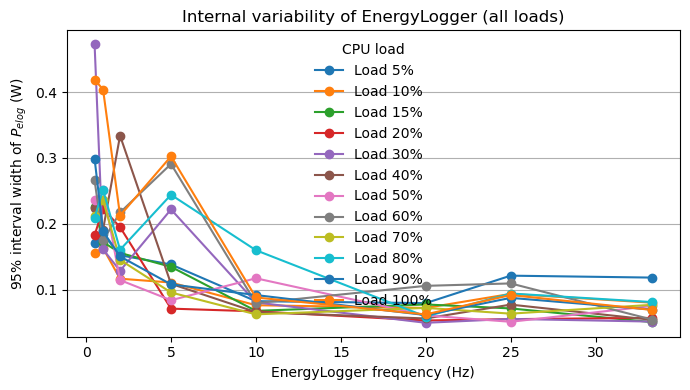

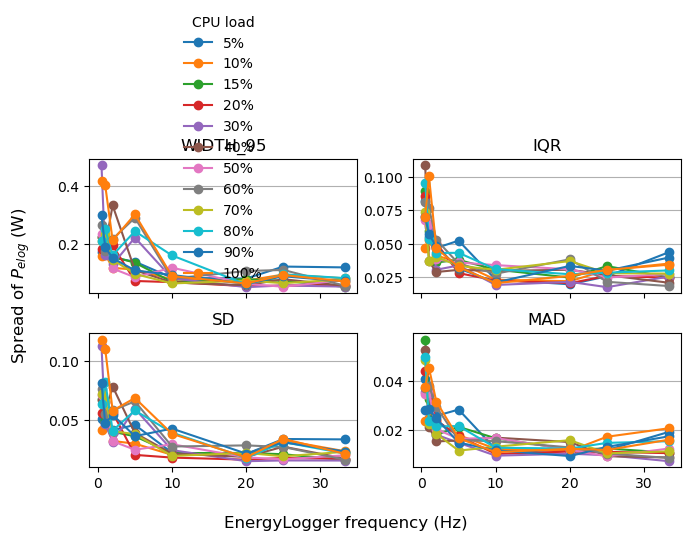

In [153]:
# Not included in the article - shows the spread metrics per load

def spread_metrics(x):
    return pd.Series({
        "n": len(x),
        "sd": x.std(ddof=1),
        "iqr": x.quantile(0.75) - x.quantile(0.25),
        "mad": np.median(np.abs(x - np.median(x))),
        "width_95": x.quantile(0.975) - x.quantile(0.025),
    })

elog_spread = (
    df
    .groupby(["frequency", "load"])["power_avg_elog"]
    .apply(spread_metrics)
    .reset_index()
)

elog_spread_wide = (
    elog_spread
    .pivot(
        index=["frequency", "load"],
        columns="level_2",
        values="power_avg_elog"
    )
    .reset_index()
)


elog_spread_wide
plt.figure(figsize=(7, 4))

for load, d in elog_spread_wide.groupby("load"):
    plt.plot(
        d["frequency"],
        d["width_95"],
        marker="o",
        label=f"Load {load}%"
    )

plt.xlabel("EnergyLogger frequency (Hz)")
plt.ylabel("95% interval width of $P_{elog}$ (W)")
plt.title("Internal variability of EnergyLogger (all loads)")
plt.grid(True, axis="y")
plt.legend(title="CPU load", frameon=False)
plt.tight_layout()
plt.show()

metrics = ["width_95", "iqr", "sd", "mad"]

fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharex=True)
axes = axes.flatten()

for ax, m in zip(axes, metrics):
    for load, d in elog_spread_wide.groupby("load"):
        ax.plot(
            d["frequency"],
            d[m],
            marker="o",
            label=f"{load}%" if m == "width_95" else None
        )
    ax.set_title(m.upper())
    ax.grid(True, axis="y")

axes[0].legend(title="CPU load", frameon=False)
fig.supxlabel("EnergyLogger frequency (Hz)")
fig.supylabel("Spread of $P_{elog}$ (W)")
plt.tight_layout()
plt.show()


In [154]:
def mad(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def summarize_spread_from_series(x):
    x = x.to_numpy()
    return pd.Series({
        "n": len(x),
        "sd": np.std(x, ddof=1),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mad": mad(x),
        "width_95": np.quantile(x, 0.975) - np.quantile(x, 0.025),
        "median": np.median(x),
    })

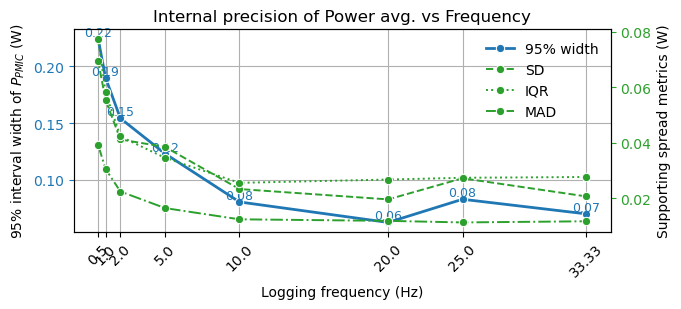

In [155]:
df_int = df_joined[df_joined["load"] > 0].copy()

df_int["frequency"] = np.where(
    df_int["period"] == 0.0,
    0,
    (1.0 / df_int["period"]).round(2)
)

S_int_fl = (
    df_int
    .groupby(["frequency", "load"])["power_avg_elog"]
    .apply(summarize_spread_from_series)
    .unstack()
    .reset_index()
)

S_int = (
    S_int_fl
    .groupby("frequency")[["sd", "iqr", "mad", "width_95"]]
    .median()
    .reset_index()
    .sort_values("frequency")
)



# convert to mW if desired
S_mW = S_int.copy()
#for c in ["sd", "iqr", "mad", "width_95"]:
#    S_mW[c] *= 1000

#######


metrics = [
    ("width_95", "95% width"),
    ("iqr",       "IQR"),
    ("sd",        "SD"),
    ("mad",       "MAD"),
]


fig, ax1 = plt.subplots(figsize=(7.0, 3.2))

# ---------- Primary metric (LEFT y-axis) ----------
sns.lineplot(
    data=S_mW,
    x="frequency",
    y="width_95",
    marker="o",
    linewidth=2.0,
    label="95% width",
    color="tab:blue",
    ax=ax1,
)

ax1.set_xscale("linear")
ax1.set_xticks(S_mW["frequency"])
ax1.set_xticklabels([str(p) for p in S_mW["frequency"]], rotation=45)

ax1.set_xlabel("Logging frequency (Hz)")
ax1.set_ylabel("95% interval width of $P_{PMIC}$ (W)")
ax1.grid(True, which="both", axis="both")
ax1.tick_params(axis="y", colors="tab:blue")
ax1.spines["left"].set_color("tab:blue")

# annotate primary metric
for _, r in S_mW.iterrows():
    ax1.text(
        r["frequency"],
        r["width_95"],
        f"{r['width_95']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="tab:blue",
    )

# ---------- Supporting metrics (RIGHT y-axis) ----------
ax2 = ax1.twinx()

sns.lineplot(
    data=S_mW, x="frequency", y="sd",
    marker="o", linestyle="--", linewidth=1.4,
    color="tab:green",
    label="SD", ax=ax2,
)
sns.lineplot(
    data=S_mW, x="frequency", y="iqr",
    marker="o", linestyle=":", linewidth=1.4,
    color="tab:green",
    label="IQR", ax=ax2,
)
sns.lineplot(
    data=S_mW, x="frequency", y="mad",
    marker="o", linestyle="-.", linewidth=1.4,
    color="tab:green",
    label="MAD", ax=ax2,
)

ax2.set_ylabel("Supporting spread metrics (W)")
ax2.spines["right"].set_color("black")
ax2.tick_params(axis="y", colors="tab:green")
# ---------- Combined legend ----------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=False,
)
ax2.legend_.remove()

# ---------- Title & layout ----------
ax1.set_title("Internal precision of Power avg. vs Frequency")
plt.tight_layout()
plt.savefig("internal-precision-combined.png", dpi=300)
plt.show()


## The data at a glance


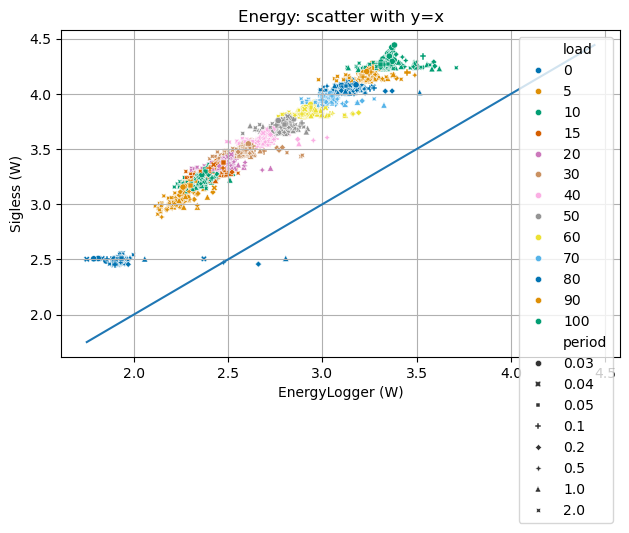

In [162]:

ax = sns.scatterplot(data=df_joined, x='power_avg_elog', y='power_avg_sig', s=20,hue='load',palette='colorblind',style='period')

mn = min(df_joined["power_avg_elog"].min(), df_joined["power_avg_sig"].min())
mx = max(df_joined["power_avg_elog"].max(), df_joined["power_avg_sig"].max())
ax.plot([mn, mx], [mn, mx])  # y=x reference

plt.tight_layout()
ax.grid(True, which="both") 
ax.set_xlabel("EnergyLogger (W)")
ax.set_ylabel("Sigless (W)")
ax.set_title("Energy: scatter with y=x")
plt.show()

/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_63762/734052677.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # leave space for legend


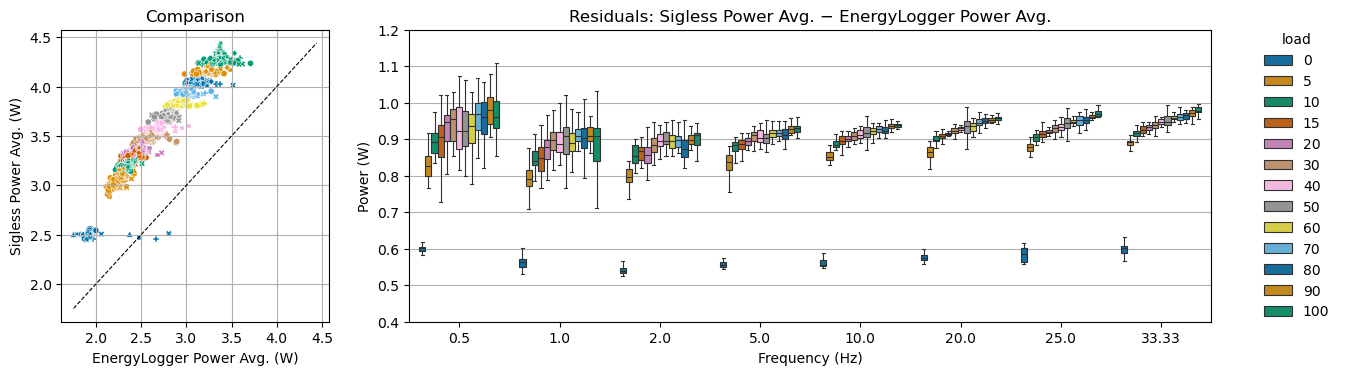

In [164]:


df_joined["residual_W"] = (
    df_joined["power_avg_sig"] - df_joined["power_avg_elog"]
)


fig = plt.figure(figsize=(20, 4.0))  # IEEE double-column height
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.15)

ax0 = fig.add_subplot(gs[0])  # scatter (narrow)
ax1 = fig.add_subplot(gs[1])  # boxplot (wide)

fig.subplots_adjust(bottom=0.15, right=0.7)

# ---------- LEFT: scatter ----------
sns.scatterplot(
    data=df_joined,
    x="power_avg_elog",
    y="power_avg_sig",
    hue="load",
    style="frequency",
    palette="colorblind",
    s=20,
    legend=False,   # suppress here
    ax=ax0,
)

mn = min(df_joined["power_avg_elog"].min(),
         df_joined["power_avg_sig"].min())
mx = max(df_joined["power_avg_elog"].max(),
         df_joined["power_avg_sig"].max())

ax0.plot([mn, mx], [mn, mx], "--", color="black", linewidth=0.8)

ax0.set_xlabel("EnergyLogger Power Avg. (W)")
ax0.set_ylabel("Sigless Power Avg. (W)")
ax0.set_title("Comparison")
ax0.grid(True, which="both")

# ---------- RIGHT: residual boxplot ----------
order = sorted(df_joined["frequency"].unique())

sns.boxplot(
    data=df_joined,
    x="frequency",
    y="residual_W",
    hue="load",
    order=order,
    palette="colorblind",
    showfliers=False,
    linewidth=0.8,
    ax=ax1,
)

ax1.axhline(0, linestyle="--", color="black", linewidth=0.8)
ax1.set_ylim(0.4, 1.2)

ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Power (W)")
ax1.set_title("Residuals: Sigless Power Avg. − EnergyLogger Power Avg.")
ax1.grid(True, axis="y")

# ---------- MOVE ORIGINAL LEGEND TO THE RIGHT ----------
legend = ax1.legend_
legend.set_bbox_to_anchor((1.05, 0.5))  # right of plots
legend.set_loc("center left")
legend.set_frame_on(False)

plt.tight_layout()  # leave space for legend
plt.savefig('overview-agreement.png')
plt.show()


# Pearson's correlation

In [70]:
g = df_joined[df_joined["load"] > 0]
r, p_r = pearsonr(g["power_avg_elog"], g["power_avg_sig"])
rho, p_rho = spearmanr(g["power_avg_elog"], g["power_avg_sig"])
print(f" n={len(g)} | Pearson r={r:.4f} (p={p_r:.1e}) | Spearman ρ={rho:.4f} (p={p_rho:.1e})")

 n=3360 | Pearson r=0.9891 (p=0.0e+00) | Spearman ρ=0.9902 (p=0.0e+00)


In [72]:
for period, g in (df_joined[df_joined["load"] > 0]
                  .dropna(subset=["power_avg_elog","power_avg_sig"])
                  .groupby("period")):
    r, p_r = pearsonr(g["power_avg_elog"], g["power_avg_sig"])
    rho, p_rho = spearmanr(g["power_avg_elog"], g["power_avg_sig"])
    print(f"period={period}: n={len(g)} | Pearson r={r:.4f} (p={p_r:.1e}) | Spearman ρ={rho:.4f} (p={p_rho:.1e})")

period=0.03: n=420 | Pearson r=0.9985 (p=0.0e+00) | Spearman ρ=0.9978 (p=0.0e+00)
period=0.04: n=420 | Pearson r=0.9972 (p=0.0e+00) | Spearman ρ=0.9963 (p=0.0e+00)
period=0.05: n=420 | Pearson r=0.9986 (p=0.0e+00) | Spearman ρ=0.9979 (p=0.0e+00)
period=0.1: n=420 | Pearson r=0.9970 (p=0.0e+00) | Spearman ρ=0.9968 (p=0.0e+00)
period=0.2: n=420 | Pearson r=0.9915 (p=0.0e+00) | Spearman ρ=0.9922 (p=0.0e+00)
period=0.5: n=420 | Pearson r=0.9906 (p=0.0e+00) | Spearman ρ=0.9913 (p=0.0e+00)
period=1.0: n=420 | Pearson r=0.9829 (p=2.2e-309) | Spearman ρ=0.9856 (p=0.0e+00)
period=2.0: n=420 | Pearson r=0.9771 (p=6.2e-283) | Spearman ρ=0.9797 (p=5.6e-294)


### Testing "how fast should we log with energylogger to get reliable results"

<>:117: SyntaxWarning: invalid escape sequence '\D'
<>:117: SyntaxWarning: invalid escape sequence '\D'
/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_63762/3884071544.py:117: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel("95% interval width of $\Delta P$ (W)")
/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_63762/3884071544.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_spread)


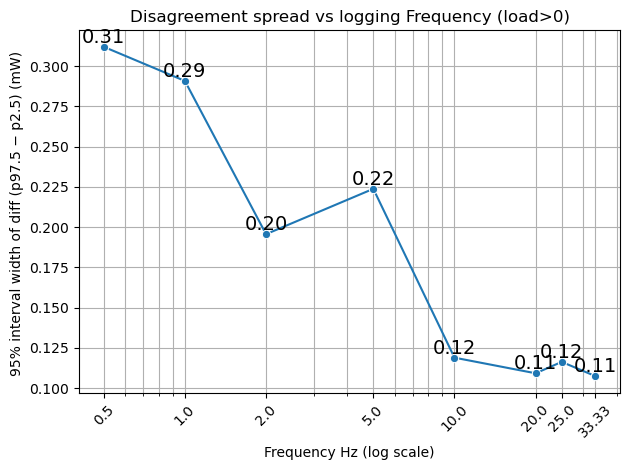

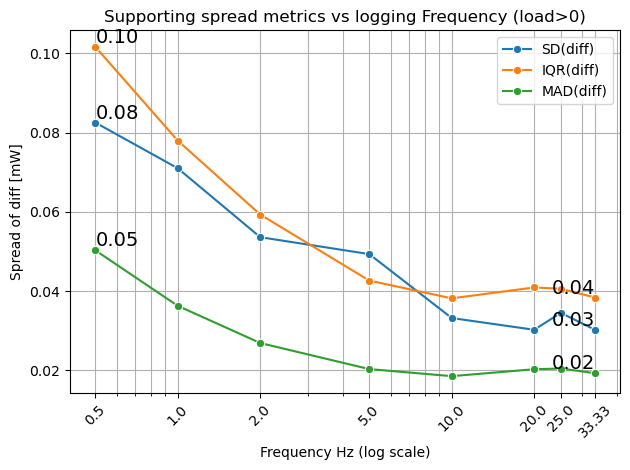

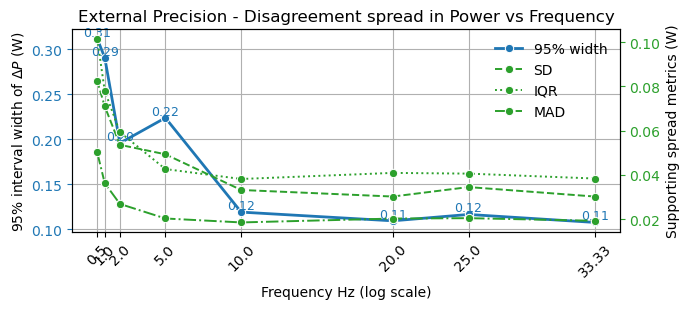

In [60]:
# If not already present:
df2 = df_joined[df_joined["load"] > 0].copy()
df2["diff"] = df2["power_avg_elog"] - df2["power_avg_sig"]

df2['frequency'] = np.where(
    df2["period"] == 0.0,
    0,  # if period == 0.0 → 0 logs (no energy logging)
    (1.0/df2["period"]).round(2)  # otherwise normal formula
)

def mad(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def summarize_spread(g):
    x = g["diff"].to_numpy()
    return pd.Series({
        "n": len(x),
        "sd": np.std(x, ddof=1),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "mad": mad(x),
        "loa_width": np.quantile(x, 0.975) - np.quantile(x, 0.025),
        "median_bias": np.median(x),
    })

S = (df2.groupby("frequency")
       .apply(summarize_spread)
       .reset_index()
       .sort_values("frequency"))

S_mW = S.copy()
for c in ["sd","iqr","mad","loa_width","median_bias"]:
    #S_mW[c] = 1000 * S_mW[c]
    S_mW[c] = S_mW[c]

# ---- Plot LoA width vs period (recommended primary) ----
# --- Figure 1: Primary (Bland–Altman spread) ---
plt.figure()
ax = sns.lineplot(data=S_mW, x="frequency", y="loa_width", marker="o")
ax.set_xscale("log")
ax.set_xticks(S_mW["frequency"])
ax.set_xticklabels([str(p) for p in S_mW["frequency"]], rotation=45)

ax.set_xlabel("Frequency Hz (log scale)")
ax.set_ylabel("95% interval width of diff (p97.5 − p2.5) (mW) ")
ax.set_title("Disagreement spread vs logging Frequency (load>0)")

# optional: annotate points
for _, r in S_mW.iterrows():
    ax.text(r["frequency"], r["loa_width"], f"{r['loa_width']:.2f}", va="bottom", ha="center", fontsize=14)

plt.tight_layout()
ax.grid(True, which="both")    
plt.savefig('disagreement-spread.png')
plt.show()



# --- Figure 2: Supporting (multiple spread metrics) ---
plt.figure()
ax = sns.lineplot(data=S_mW, x="frequency", y="sd", marker="o", label="SD(diff)")
sns.lineplot(data=S_mW, x="frequency", y="iqr", marker="o", label="IQR(diff)", ax=ax)
sns.lineplot(data=S_mW, x="frequency", y="mad", marker="o", label="MAD(diff)", ax=ax)

ax.set_xscale("log")
ax.set_xticks(S_mW["frequency"])
ax.set_xticklabels([str(p) for p in S_mW["frequency"]], rotation=45)
# annotate only first + last period for each metric
first = S_mW.iloc[0]
last  = S_mW.iloc[-1]


    
for metric in ["sd", "iqr", "mad"]:
    ax.text(first["frequency"], first[metric], f"{first[metric]:.2f}", va="bottom", ha="left", fontsize=14)
    ax.text(last["frequency"],  last[metric],  f"{last[metric]:.2f}",  va="bottom", ha="right", fontsize=14)

ax.set_xlabel("Frequency Hz (log scale)")
ax.set_ylabel("Spread of diff [mW]")
ax.set_title("Supporting spread metrics vs logging Frequency (load>0)")
ax.grid(True, which="both")    
plt.tight_layout()
plt.savefig('supporting-spread.png')
plt.show()


# ----------  Udpdated figure 

metrics = [
    ("loa_width", "95% width"),
    ("iqr",       "IQR"),
    ("sd",        "SD"),
    ("mad",       "MAD"),
]


fig, ax1 = plt.subplots(figsize=(7.0, 3.2))

# ---------- Primary metric (LEFT y-axis) ----------
sns.lineplot(
    data=S_mW,
    x="frequency",
    y="loa_width",
    marker="o",
    linewidth=2.0,
    label="95% width",
    color="tab:blue",
    ax=ax1,
)

ax1.set_xscale("linear")
ax1.set_xticks(S_mW["frequency"])
ax1.set_xticklabels([str(p) for p in S_mW["frequency"]], rotation=45)

ax1.set_xlabel("Frequency Hz (log scale)")
ax1.set_ylabel("95% interval width of $\Delta P$ (W)")
ax1.grid(True, which="both", axis="both")
ax1.tick_params(axis="y", colors="tab:blue")
ax1.spines["left"].set_color("tab:blue")

# annotate primary metric
for _, r in S_mW.iterrows():
    ax1.text(
        r["frequency"],
        r["loa_width"],
        f"{r['loa_width']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="tab:blue",
    )

# ---------- Supporting metrics (RIGHT y-axis) ----------
ax2 = ax1.twinx()

sns.lineplot(
    data=S_mW, x="frequency", y="sd",
    marker="o", linestyle="--", linewidth=1.4,
    color="tab:green",
    label="SD", ax=ax2,
)
sns.lineplot(
    data=S_mW, x="frequency", y="iqr",
    marker="o", linestyle=":", linewidth=1.4,
    color="tab:green",
    label="IQR", ax=ax2,
)
sns.lineplot(
    data=S_mW, x="frequency", y="mad",
    marker="o", linestyle="-.", linewidth=1.4,
    color="tab:green",
    label="MAD", ax=ax2,
)

ax2.set_ylabel("Supporting spread metrics (W)")
ax2.spines["right"].set_color("black")
ax2.tick_params(axis="y", colors="tab:green")
# ---------- Combined legend ----------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=False,
)
ax2.legend_.remove()

# ---------- Title & layout ----------
ax1.set_title("External Precision - Disagreement spread in Power vs Frequency")
plt.tight_layout()
plt.savefig("diff-precision-combined.png", dpi=300)
plt.show()

## Figure 1:

The y-value is: **how wide the central 95% band of disagreement is.**
We see
- A low, fairly flat region at short periods (0.03–0.10), around 0.107–0.119 W.
- A jump (“elbow”) at 0.20, where the width roughly doubles 0.224 W.
- A continued increase for 0.50–2.00, ending around 0.291–0.312 W.
**The 95% disagreement band widens by about ~3× from fast sampling to slow sampling.**

## Figure 2:
All three are measures of spread of diff, but they behave differently under non-normality:
- SD(diff): standard deviation (sensitive to tails/outliers)
- IQR(diff): middle 50% spread (robust)
- MAD(diff): median absolute deviation (very robust)

We see:
- SD, IQR, and MAD all increase with period
-  SD shows an overall increasing trend with logging period, since SD reacts to heavy tails and outlier it has minor non-monotone fluctuations at the shortest periods (0.03–0.10)
- IQR and MAD increase more smoothly, indicating that the core spread increases with period even when SD varies slightly due to tail sensitivity

There is a clear trade-off: increasing period (sampling less often) increases the uncertainty/spread of EnergyLogger’s energy estimate relative to Sigless.

We observe an apparent knee around 0.10–0.20: up to 0.10 the spread is low; at 0.20 it increases.
This supports a recommendation : **“Choose period ≤ 0.10 to keep disagreement spread low; larger periods substantially worsen the agreement between EnergyLogger and the external measurements.”**

In [100]:
S

,frequency,n,sd,iqr,mad,loa_width,median_bias
0,0.50,420.0,0.082550,0.101650,0.050308,0.311957,-0.929328
1,1.00,420.0,0.071000,0.077976,0.036293,0.290767,-0.884852
2,2.00,420.0,0.053616,0.059321,0.026910,0.195633,-0.882054
3,5.00,420.0,0.049344,0.042663,0.020330,0.223788,-0.903429
4,10.00,420.0,0.033216,0.038177,0.018549,0.118967,-0.913752
5,20.00,420.0,0.030248,0.040933,0.020297,0.109271,-0.928684
6,25.00,420.0,0.034524,0.040602,0.020478,0.116352,-0.935810
7,33.33,420.0,0.030248,0.038393,0.019293,0.107487,-0.945926


In [102]:
from scipy.stats import spearmanr, kendalltau

metrics = ["sd", "iqr", "mad", "loa_width"]
for m in metrics:
    rho, p = spearmanr(S["period"], S[m])
    tau, p2 = kendalltau(S["period"], S[m])
    print(m, "Spearman rho:", rho, "p:", p, "| Kendall tau:", tau, "p:", p2)


KeyError: 'period'

**Although SD is not strictly monotone across the smallest periods, rank-based association tests show a clear increasing trend in spread with increasing logging period (e.g., LoA width: Spearman ρ=0.95, Kendall τ=0.86; SD: ρ=0.88; all p<0.01)**

## Second "Data at a glance"

In [106]:
df_tight = df_joined[df_joined['period']==0.03]

In [108]:
from scipy.stats import pearsonr, spearmanr

sub = df_tight[(df_tight["load"] > 0)].dropna(subset=["power_avg_elog", "power_avg_sig"])

r, p_r = pearsonr(sub["power_avg_elog"], sub["power_avg_sig"])
rho, p_rho = spearmanr(sub["power_avg_elog"], sub["power_avg_sig"])

print(f"Pearson r = {r:.4f} (p={p_r:.2e})")
print(f"Spearman ρ = {rho:.4f} (p={p_rho:.2e})")
print("n =", len(sub))

Pearson r = 0.9985 (p=0.00e+00)
Spearman ρ = 0.9978 (p=0.00e+00)
n = 420


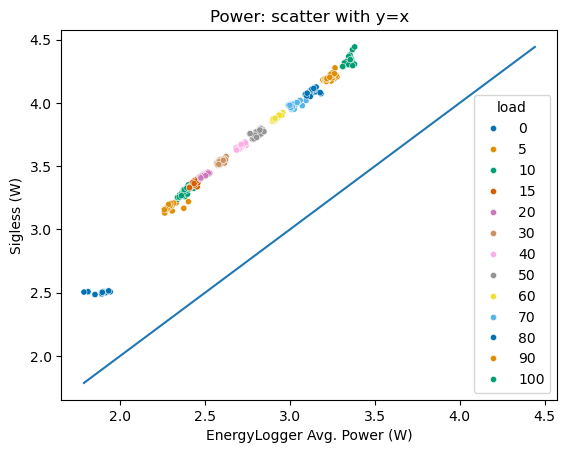

In [431]:

ax = sns.scatterplot(data=df_tight, x='power_avg_elog', y='power_avg_sig', s=20,hue='load',palette='colorblind')

mn = min(df_tight["power_avg_elog"].min(), df_tight["power_avg_sig"].min())
mx = max(df_tight["power_avg_elog"].max(), df_tight["power_avg_sig"].max())
ax.plot([mn, mx], [mn, mx])  # y=x reference

ax.set_xlabel("EnergyLogger Avg. Power (W)")
ax.set_ylabel("Sigless (W)")
ax.set_title("Power: scatter with y=x")
plt.show()

In [369]:
df_joined["period"].unique()

array([0.05, 1.  , 0.1 , 0.03, 2.  , 0.5 , 0.04, 0.2 ])

Train params: {'const': 0.7542221811009208, 'power_avg_elog': 1.0681974265707106}
Validation (period=0.04) RMSE: 0.029234261681267387
Validation (period=0.04) MAE: 0.016805027127340166
Validation bias (median pred - sig): 0.007824157323169434
Validation LoA: (-0.023771907778877808, 0.06877970587227167)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


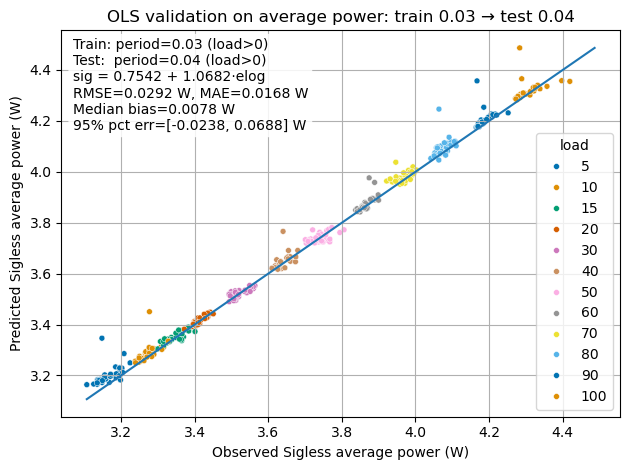

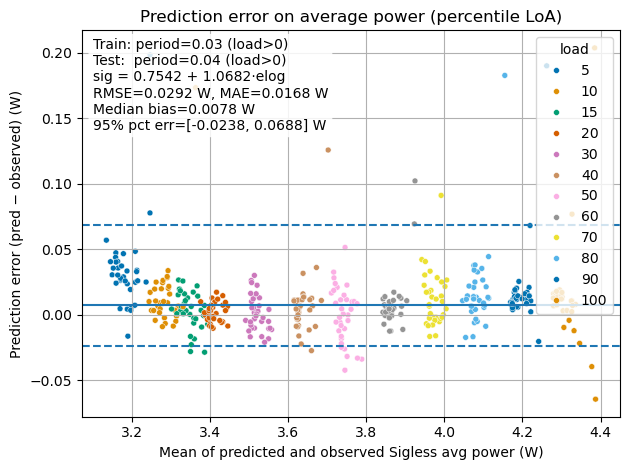

In [437]:
train = df_joined[(df_joined["period"] == 0.03) & (df_joined["load"] > 0)].dropna(
    subset=["power_avg_elog","power_avg_sig"]
)
test  = df_joined[(df_joined["period"] == 0.04) & (df_joined["load"] > 0)].dropna(
    subset=["power_avg_elog","power_avg_sig"]
)

# Fit on 0.03: power_sig ~ a + b * power_elog
Xtr = sm.add_constant(train["power_avg_elog"])
ytr = train["power_avg_sig"]
m = sm.OLS(ytr, Xtr).fit()
print("Train params:", m.params.to_dict())

# Predict on 0.04
Xte = sm.add_constant(test["power_avg_elog"])
yte = test["power_avg_sig"]
pred = m.predict(Xte)

rmse = mean_squared_error(yte, pred, squared=False)
mae  = mean_absolute_error(yte, pred)

err = pred - yte
bias_med = float(err.median())
loa_low, loa_high = err.quantile([0.025, 0.975])

print("Validation (period=0.04) RMSE:", rmse)
print("Validation (period=0.04) MAE:", mae)
print("Validation bias (median pred - sig):", bias_med)
print("Validation LoA:", (float(loa_low), float(loa_high)))

# Build plotting frame
out = test.copy()
out["pred_sig"] = pred
out["err"] = err
out["mean_pred_obs"] = (out["pred_sig"] + out["power_avg_sig"]) / 2

# Textbox for plots
textbox = (
    f"Train: period=0.03 (load>0)\n"
    f"Test:  period=0.04 (load>0)\n"
    f"sig = {m.params['const']:.4f} + {m.params['power_avg_elog']:.4f}·elog\n"
    f"RMSE={rmse:.4f} W, MAE={mae:.4f} W\n"
    f"Median bias={bias_med:.4f} W\n"
    f"95% pct err=[{loa_low:.4f}, {loa_high:.4f}] W"
)

# -----------------------------
# Figure 1: Observed vs Predicted (with y=x)
# -----------------------------
plt.figure()
ax = sns.scatterplot(data=out, x="power_avg_sig", y="pred_sig", s=18,hue='load',palette='colorblind')
mn = float(min(out["power_avg_sig"].min(), out["pred_sig"].min()))
mx = float(max(out["power_avg_sig"].max(), out["pred_sig"].max()))
ax.plot([mn, mx], [mn, mx])  # y=x
ax.set_xlabel("Observed Sigless average power (W)")
ax.set_ylabel("Predicted Sigless average power (W)")
ax.set_title("OLS validation on average power: train 0.03 → test 0.04")
ax.text(
    0.02, 0.98, textbox,
    transform=ax.transAxes, va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
)
ax.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Figure 2: Prediction error vs magnitude (Bland–Altman-style)
# -----------------------------
plt.figure()
ax = sns.scatterplot(data=out, x="mean_pred_obs", y="err", s=18,hue='load',palette='colorblind')
ax.axhline(bias_med)
ax.axhline(loa_low, linestyle="--")
ax.axhline(loa_high, linestyle="--")
ax.set_xlabel("Mean of predicted and observed Sigless avg power (W)")
ax.set_ylabel("Prediction error (pred − observed) (W)")
ax.set_title("Prediction error on average power (percentile LoA)")
ax.text(
    0.02, 0.98, textbox,
    transform=ax.transAxes, va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
)
ax.grid(True)
plt.tight_layout()
plt.show()

In [439]:
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:          power_avg_sig   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.414e+05
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:10:23   Log-Likelihood:                 1055.9
No. Observations:                 420   AIC:                            -2108.
Df Residuals:                     418   BIC:                            -2100.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.7542      0.008     94.

In [441]:
print(test["power_avg_sig"].describe())

count    420.000000
mean       3.708354
std        0.359991
min        3.106950
25%        3.390937
50%        3.690441
75%        4.012360
max        4.419360
Name: power_avg_sig, dtype: float64


In [114]:
df2

,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig,diff,frequency
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843,-0.881810,20.00
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701,-0.908897,10.00
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361,-0.941361,33.33
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295,-0.882191,10.00
5,27,80,0.03,79.979996,249.146805,3.115114,80.029,326.462375,4.079301,-0.964187,33.33
...,...,...,...,...,...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799,80.022,266.337175,3.328299,-0.855501,10.00
3636,19,20,0.10,79.910687,197.668477,2.473618,80.021,270.732975,3.383274,-0.909657,10.00
3637,30,90,0.50,79.509807,260.785285,3.279913,80.023,334.061200,4.174565,-0.894651,2.00
3638,33,60,0.04,79.959994,232.368739,2.906062,80.023,308.952000,3.860790,-0.954728,25.00


In [130]:
df = df2.copy()

df_rec = df[(df["load"] > 0) & (df["frequency"] >= 10)].copy()   # recommended region

def bias_summary(g):
    return pd.Series({
        "n": len(g),
        "median_sig_J": g["energy_sig"].median(),
        "median_elog_J": g["energy_elog"].median(),
        "median_diff_J": g["diff"].median(),
        "median_bias_pct": 100 * g["diff"].median() / g["energy_sig"].median(),
        "loa_width_J": g["diff"].quantile(0.975) - g["diff"].quantile(0.025),
    })

# overall recommended-region summary
S_rec_overall = bias_summary(df_rec).to_frame().T
display(S_rec_overall)

# optionally: per frequency inside the recommended region
S_rec_byfreq = (df_rec.groupby("frequency")
                      .apply(bias_summary)
                      .reset_index()
                      .sort_values("frequency"))
display(S_rec_byfreq)

,n,median_sig_J,median_elog_J,median_diff_J,median_bias_pct,loa_width_J
0,1680.0,294.720775,220.631582,-0.930613,-0.315761,0.131333


/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_47754/4089062136.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(bias_summary)


,frequency,n,median_sig_J,median_elog_J,median_diff_J,median_bias_pct,loa_width_J
0,10.00,420.0,292.606375,220.180572,-0.913752,-0.312280,0.118967
1,20.00,420.0,294.153112,220.085545,-0.928684,-0.315714,0.109271
2,25.00,420.0,295.316462,222.060659,-0.935810,-0.316884,0.116352
3,33.33,420.0,296.403338,220.166731,-0.945926,-0.319135,0.107487


In [64]:
df2

,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig,frequency,diff
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843,20.00,-0.881810
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701,10.00,-0.908897
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361,33.33,-0.941361
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295,10.00,-0.882191
5,27,80,0.03,79.979996,249.146805,3.115114,80.029,326.462375,4.079301,33.33,-0.964187
...,...,...,...,...,...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799,80.022,266.337175,3.328299,10.00,-0.855501
3636,19,20,0.10,79.910687,197.668477,2.473618,80.021,270.732975,3.383274,10.00,-0.909657
3637,30,90,0.50,79.509807,260.785285,3.279913,80.023,334.061200,4.174565,2.00,-0.894651
3638,33,60,0.04,79.959994,232.368739,2.906062,80.023,308.952000,3.860790,25.00,-0.954728


/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_47754/637716211.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


   frequency      n  median_sig_J  median_elog_J  median_bias_J  \
0       0.50  420.0    289.725900     215.785867     -73.940033   
1       1.00  420.0    291.136400     216.554538     -74.581862   
2       2.00  420.0    290.451250     218.175456     -72.275794   
3       5.00  420.0    291.308325     220.644388     -70.663937   
4      10.00  420.0    292.606375     220.180572     -72.425803   
5      20.00  420.0    294.153112     220.085545     -74.067567   
6      25.00  420.0    295.316462     222.060659     -73.255803   
7      33.33  420.0    296.403338     220.166731     -76.236607   

   median_bias_pct  loa_width_J  
0       -25.520684     0.311957  
1       -25.617498     0.290767  
2       -24.883967     0.195633  
3       -24.257438     0.223788  
4       -24.751957     0.118967  
5       -25.179937     0.109271  
6       -24.805865     0.116352  
7       -25.720563     0.107487  


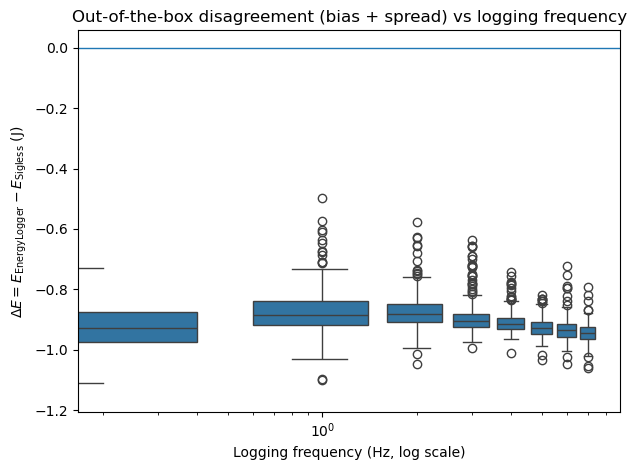

In [136]:
#df = df2[(df2["load"] > 0) & (df2["frequency"] >= 10)].copy()
df = df2.copy()

# Summary table per frequency
S = (df.groupby("frequency")
       .apply(lambda g: pd.Series({
           "n": len(g),
           "median_sig_J": g["energy_sig"].median(),
           "median_elog_J": g["energy_elog"].median(),
           "median_bias_J": (g["energy_elog"].median() - g["energy_sig"].median()),
           "median_bias_pct": 100*(g["energy_elog"].median() - g["energy_sig"].median())/g["energy_sig"].median(),
           "loa_width_J": g["diff"].quantile(0.975) - g["diff"].quantile(0.025),  # central 95% width
       }))
       .reset_index()
       .sort_values("frequency"))

print(S)

# Plot: bias distribution by frequency (boxplot)
plt.figure()
ax = sns.boxplot(data=df, x="frequency", y="diff")
ax.set_xscale("log")
ax.set_xlabel("Logging frequency (Hz, log scale)")
ax.set_ylabel(r"$\Delta E = E_{\mathrm{EnergyLogger}} - E_{\mathrm{Sigless}}$ (J)")
ax.set_title("Out-of-the-box disagreement (bias + spread) vs logging frequency")
ax.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [68]:
df2.head()

,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig,frequency,diff
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843,20.00,-0.881810
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701,10.00,-0.908897
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361,33.33,-0.941361
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295,10.00,-0.882191
5,27,80,0.03,79.979996,249.146805,3.115114,80.029,326.462375,4.079301,33.33,-0.964187


In [106]:
### Absolute agreement on power for EnergyLogger and External

#df = df2[(df2["load"] > 0) & (df2["frequency"] >= 10)].copy()
df = df2.copy()

# Summary table per frequency
S = (df.groupby("frequency")
       .apply(lambda g: pd.Series({
           "n": len(g),
           "mean_pmic_W": g["power_avg_elog"].mean(),
           "mean_ext_W": g["power_avg_sig"].mean(),
           "mean_bias_W": (g["power_avg_elog"].mean() - g["power_avg_sig"].mean()),
           "mean_bias_pct": 100*(g["power_avg_elog"].mean() - g["power_avg_sig"].mean())/g["power_avg_sig"].mean(),
          # "loa_width_J": g["diff"].quantile(0.975) - g["diff"].quantile(0.025),  # central 95% width
       }))
       .reset_index()
       .sort_values("frequency"))
#print(S)
S = S.set_index('frequency')
S = S.style.format(decimal='.', thousands=',', precision=2)
print(S.to_latex())


\begin{tabular}{lrrrrr}
 & n & mean_pmic_W & mean_ext_W & mean_bias_W & mean_bias_pct \\
frequency &  &  &  &  &  \\
0.500000 & 420.00 & 2.72 & 3.64 & -0.92 & -25.32 \\
1.000000 & 420.00 & 2.77 & 3.64 & -0.88 & -24.03 \\
2.000000 & 420.00 & 2.78 & 3.65 & -0.87 & -23.93 \\
5.000000 & 420.00 & 2.77 & 3.67 & -0.89 & -24.38 \\
10.000000 & 420.00 & 2.77 & 3.68 & -0.91 & -24.65 \\
20.000000 & 420.00 & 2.77 & 3.70 & -0.93 & -25.01 \\
25.000000 & 420.00 & 2.78 & 3.71 & -0.93 & -25.14 \\
33.330000 & 420.00 & 2.78 & 3.72 & -0.94 & -25.36 \\
\end{tabular}



/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_63762/1801032098.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [110]:
df.to_csv('test.csv')

   frequency  kendall_tau  pairwise_concordance    n
0       0.50     0.877736              0.938868  420
1       1.00     0.900739              0.950369  420
2       2.00     0.925242              0.962621  420
3       5.00     0.935015              0.967508  420
4      10.00     0.956404              0.978202  420
5      20.00     0.962928              0.981464  420
6      25.00     0.957222              0.978611  420
7      33.33     0.962109              0.981055  420


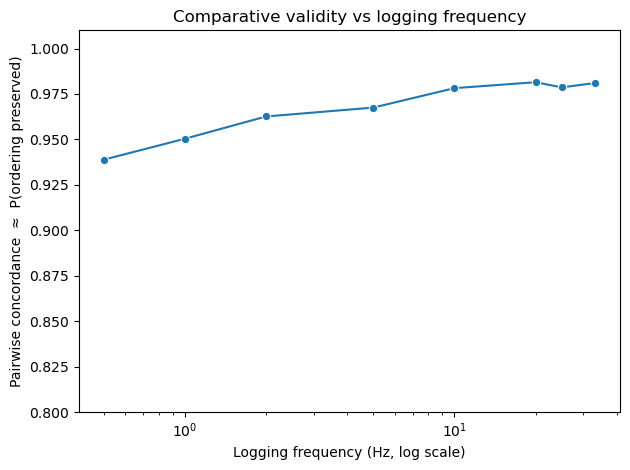

In [138]:
from scipy.stats import kendalltau

rows = []
for freq, g in df.groupby("frequency"):
    tau, _ = kendalltau(g["energy_elog"], g["energy_sig"])
    rows.append({
        "frequency": freq,
        "kendall_tau": tau,
        "pairwise_concordance": (tau + 1) / 2,   # ~ P(ordering preserved)
        "n": len(g)
    })

C = pd.DataFrame(rows).sort_values("frequency")
print(C)

plt.figure()
ax = sns.lineplot(data=C, x="frequency", y="pairwise_concordance", marker="o")
ax.set_xscale("log")
ax.set_xlabel("Logging frequency (Hz, log scale)")
ax.set_ylabel("Pairwise concordance  ≈  P(ordering preserved)")
ax.set_title("Comparative validity vs logging frequency")
ax.set_ylim(0.8, 1.01)
plt.grid(
plt.tight_layout()
plt.show()


/var/folders/v5/7jxn000s4bj5xzgtytbkndv80000gn/T/ipykernel_47754/2270960265.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return out.groupby("bin").agg(n=("agree","size"), correct_order_rate=("agree","mean"))


                n  correct_order_rate
bin                                  
[0, 1)       3791            0.567133
[1, 2)       3450            0.696812
[2, 5)       7853            0.896091
[5, 10)     14971            0.987643
[10, 20)    25646            0.997465
[20, 50)    55938            1.000000
[50, 100)   38221            1.000000
[100, 200)     50            1.000000
[200, 500)      0                 NaN


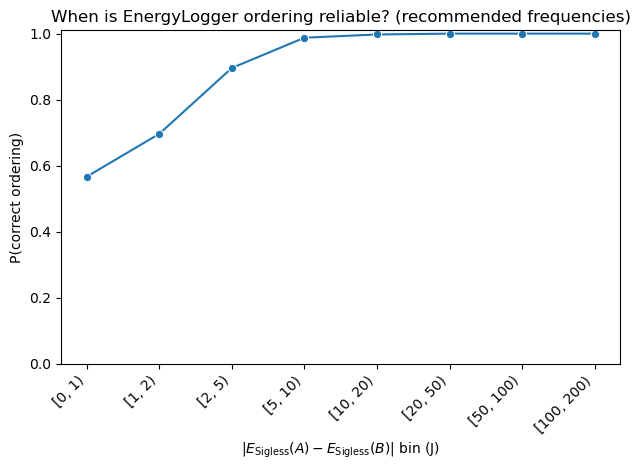

In [128]:
rng = np.random.default_rng(0)

def order_accuracy_vs_margin(g, n_pairs=100000, bins=(0, 1, 2, 5, 10, 20, 50, 100, 200, 500)):
    # bins in Joules; adjust to your scale
    x = g["energy_sig"].to_numpy()
    y = g["energy_elog"].to_numpy()
    n = len(g)

    i = rng.integers(0, n, size=n_pairs)
    j = rng.integers(0, n, size=n_pairs)
    keep = i != j
    i, j = i[keep], j[keep]

    d_sig = x[i] - x[j]
    d_elog = y[i] - y[j]

    # remove ties in external (very close to zero)
    eps = 1e-12
    keep = np.abs(d_sig) > eps
    d_sig, d_elog = d_sig[keep], d_elog[keep]

    agree = np.sign(d_sig) == np.sign(d_elog)
    abs_sig = np.abs(d_sig)

    import pandas as pd
    cat = pd.cut(abs_sig, bins=bins, right=False, include_lowest=True)
    out = pd.DataFrame({"bin": cat, "agree": agree})
    return out.groupby("bin").agg(n=("agree","size"), correct_order_rate=("agree","mean"))

# Example: do it for your “recommended” region, e.g., ≥10 Hz
g = df[df["frequency"] >= 10]
M = order_accuracy_vs_margin(g, n_pairs=150000)
print(M)

plt.figure()
ax = sns.lineplot(x=M.index.astype(str), y=M["correct_order_rate"], marker="o")
ax.set_xlabel(r"$|E_{\mathrm{Sigless}}(A)-E_{\mathrm{Sigless}}(B)|$ bin (J)")
ax.set_ylabel("P(correct ordering)")
ax.set_title("When is EnergyLogger ordering reliable? (recommended frequencies)")
ax.set_ylim(0, 1.01)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


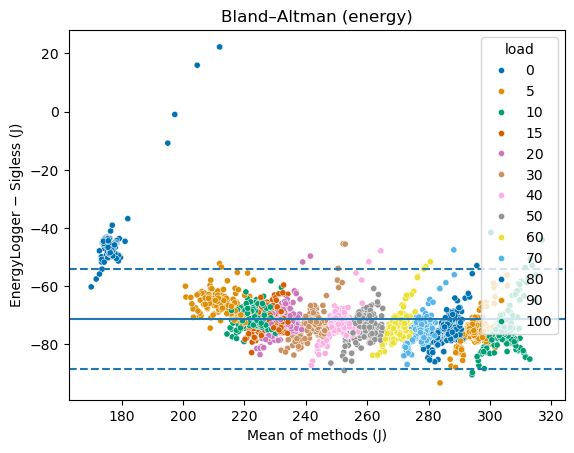

In [268]:

elog = df_joined["energy_elog"].to_numpy()
sig  = df_joined["energy_sig"].to_numpy()

mean = (elog + sig) / 2
diff = elog - sig

bias = diff.mean()
sd   = diff.std(ddof=1)
loa_low  = bias - 1.96 * sd
loa_high = bias + 1.96 * sd

ba = df_joined.copy()
ba["mean"] = mean
ba["diff"] = diff

ax = sns.scatterplot(data=ba, x="mean", y="diff", s=20,hue='load',palette='colorblind')

ax.axhline(bias)
ax.axhline(loa_low, linestyle="--")
ax.axhline(loa_high, linestyle="--")

ax.set_xlabel("Mean of methods (J)")
ax.set_ylabel("EnergyLogger − Sigless (J)")
ax.set_title("Bland–Altman (energy)")
plt.show()


In [250]:
import statsmodels.api as sm
x = df["energy_elog"].to_numpy()
y = df["energy_sig"].to_numpy()

X = sm.add_constant(x)
m = sm.OLS(y, X).fit()
print(m.params)   # intercept, slope


[3.39819754e+02 2.26854312e-04]


In [252]:
df["energy_EnergyLogger_cal"] = m.predict(X)



### 3.3 Precision of RAPL Measurements

In [232]:
# Levene’s test comparing variance between RAPL and External

# -----------------------------------------------------------
# Goal: Test whether RAPL and External measurements have
#       significantly different variances (precision check)
#       for each workload class.
# -----------------------------------------------------------
    
for info,df in df_joined.groupby(["load","period"]):
    data_elog = df["energy_elog"]
    data_ext = df["energy_sig"]
    # Levene’s test for equality of variances (center = "median" → robust to non-normality)
    stat, p = levene(data_ext, data_elog, center="median")
    
    # Compute variance difference (EnergyLogger - External)
    diff_var = data_elog.var() - data_ext.var()
    
    print(f"\n{info}: Levene’s test p = {p:.4f}, variance diff = {diff_var:.2f} (RAPL - External)")
    
    # --- Interpretation section ---
    if p < 0.05:
        print("  → Significant difference in measurement variance (p < 0.05).")
        if diff_var > 0:
            print(f"  → EnergyLogger shows HIGHER variance, indicating lower precision "
                  f"(less consistent energy readings).")
        else:
            print(f"  → EnergyLogger shows LOWER variance, indicating slightly higher precision.")
    else:
        print("  → No significant difference in measurement variance (p ≥ 0.05).")
        print("  → Interpretation: EnergyLogger and External exhibit comparable precision.")
    



(0, 0.03): Levene’s test p = 0.0036, variance diff = 5.41 (RAPL - External)
  → Significant difference in measurement variance (p < 0.05).
  → EnergyLogger shows HIGHER variance, indicating lower precision (less consistent energy readings).

(0, 0.04): Levene’s test p = 0.4717, variance diff = 43.40 (RAPL - External)
  → No significant difference in measurement variance (p ≥ 0.05).
  → Interpretation: EnergyLogger and External exhibit comparable precision.

(0, 0.05): Levene’s test p = 0.0130, variance diff = -0.77 (RAPL - External)
  → Significant difference in measurement variance (p < 0.05).
  → EnergyLogger shows LOWER variance, indicating slightly higher precision.

(0, 0.1): Levene’s test p = 0.1550, variance diff = -1.19 (RAPL - External)
  → No significant difference in measurement variance (p ≥ 0.05).
  → Interpretation: EnergyLogger and External exhibit comparable precision.

(0, 0.2): Levene’s test p = 0.3978, variance diff = 100.29 (RAPL - External)
  → No significant diff

In [112]:
df_joined 




,round,load,period,duration_elog,energy_elog,power_avg_elog,duration_sig,energy_sig,power_avg_sig
0,11,40,0.05,79.960475,218.854502,2.737034,80.022,289.587075,3.618843
1,30,0,1.00,79.509937,154.838835,1.947415,80.025,200.772075,2.508867
2,28,80,0.10,79.910289,248.425413,3.108804,80.023,321.508450,4.017701
3,10,40,0.03,79.979996,216.025933,2.701000,80.022,291.468975,3.642361
4,6,5,0.10,79.910750,185.641053,2.323105,80.022,256.494150,3.205295
...,...,...,...,...,...,...,...,...,...
3635,26,15,0.10,79.910509,197.602605,2.472799,80.022,266.337175,3.328299
3636,19,20,0.10,79.910687,197.668477,2.473618,80.021,270.732975,3.383274
3637,30,90,0.50,79.509807,260.785285,3.279913,80.023,334.061200,4.174565
3638,33,60,0.04,79.959994,232.368739,2.906062,80.023,308.952000,3.860790


### 3.4 Software Characteristica-Specific Effects

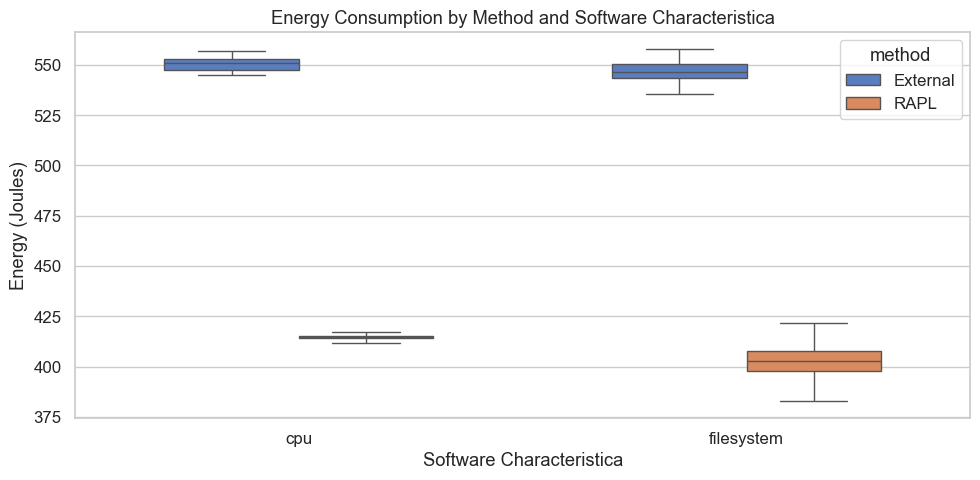

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Adjust plot style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df, x="characteristica_class", y="energy_norm20s", hue="load", showfliers=False, width=0.6)

plt.title("Energy Consumption by Method and Software Characteristica")
plt.xlabel("Software Characteristica")
plt.ylabel("Energy (Joules)")
plt.tight_layout()
plt.show()


For each method (External, RAPL), can we statistically see a significant difference in time-normalized energy between CPU and [your choice] 

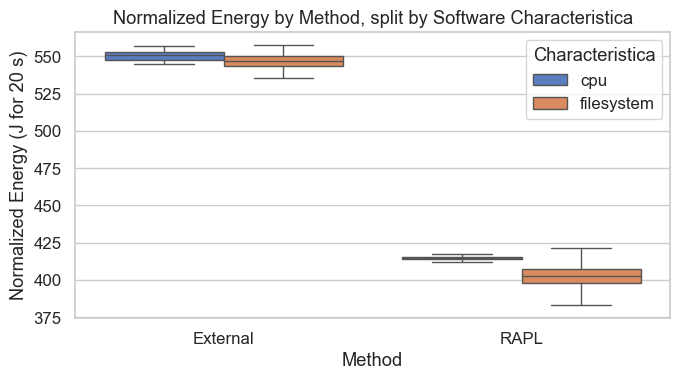

In [70]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df,
    x="method", y="energy_norm20s",
    hue="characteristica_class",
    showfliers=False
)
plt.title("Normalized Energy by Method, split by Software Characteristica")
plt.xlabel("Method")
plt.ylabel("Normalized Energy (J for 20 s)")
plt.legend(title="Characteristica")
plt.tight_layout()
plt.show()


In [72]:

# ----------------------------------------------------------------------
# Goal: For each method (External, RAPL), test if CPU vs [your choice]
#       differ in normalized energy. This reveals workload-dependent bias.

from scipy.stats import mannwhitneyu

software_characteristica_A = "cpu"
software_characteristica_B = "filesystem"

def rank_biserial_from_u(u, n1, n2):
    # Rank-biserial correlation: r_rb = 1 - 2U/(n1*n2)
    return 1 - 2 * (u / (n1 * n2))

methods = df["method"].unique()

for method in methods:
    cpu = df[(df["characteristica_class"] == software_characteristica_A) & (df["method"] == method)]["energy_norm20s"]
    fs  = df[(df["characteristica_class"] == software_characteristica_B) & (df["method"] == method)]["energy_norm20s"]

    # Mann–Whitney U (non-parametric, robust to non-normality)
    stat, p = mannwhitneyu(cpu, fs, alternative="two-sided")
    diff = fs.mean() - cpu.mean()
    r_rb = rank_biserial_from_u(stat, len(cpu), len(fs))

    print(f"\nMethod = {method}")
    print(f"  Mann–Whitney U p = {p:.4f}")
    print(f"  Mean difference ({software_characteristica_B} - {software_characteristica_A}) = {diff:.2f} J")
    print(f"  Rank-biserial correlation (effect size) r_rb = {r_rb:.3f}")

    # Interpretation
    if p < 0.05:
        print(f"  → Significant {software_characteristica_A} vs {software_characteristica_B} difference within this method.")
        if diff < 0:
            print(f"  → {software_characteristica_B} appears LOWER than {software_characteristica_A} by ~{abs(diff):.1f} J.")
        else:
            print(f"  → {software_characteristica_B} appears HIGHER than {software_characteristica_A} by ~{abs(diff):.1f} J.")
    else:
        print(f"  → No significant difference between {software_characteristica_A} and {software_characteristica_B} within this method.")

    # Method-specific context
    if method.lower() == "external":
        print("  → External reflects the *true* system energy; small differences are real but small.")
    else:
        print("  → RAPL reflects the *estimate*; larger differences indicate software characteristic-dependent bias "
              "due to incomplete power-domain coverage (e.g., I/O, peripherals).")



Method = External
  Mann–Whitney U p = 0.0116
  Mean difference (filesystem - cpu) = -2.94 J
  Rank-biserial correlation (effect size) r_rb = -0.352
  → Significant cpu vs filesystem difference within this method.
  → filesystem appears LOWER than cpu by ~2.9 J.
  → External reflects the *true* system energy; small differences are real but small.

Method = RAPL
  Mann–Whitney U p = 0.0000
  Mean difference (filesystem - cpu) = -12.24 J
  Rank-biserial correlation (effect size) r_rb = -0.847
  → Significant cpu vs filesystem difference within this method.
  → filesystem appears LOWER than cpu by ~12.2 J.
  → RAPL reflects the *estimate*; larger differences indicate software characteristic-dependent bias due to incomplete power-domain coverage (e.g., I/O, peripherals).


In [74]:
# Compute per-class mean energies
means = df.groupby(["characteristica_class", "method"])["energy_norm20s"].mean().unstack()
means["bias_RAPL_vs_External"] = means["RAPL"] - means["External"]
means

# Display the table
print("Per-class mean normalized energies (J for 20 s):\n")
print(means.round(3))
print("\n--- Interpretation ---")

# Interpret each row
for cls, row in means.iterrows():
    bias = row["bias_RAPL_vs_External"]
    print(f"\n{cls.upper()}:")
    if bias < 0:
        print(f"  → RAPL underestimates energy by {abs(bias):.2f} J compared to the external power meter.")
    elif bias > 0:
        print(f"  → RAPL overestimates energy by {bias:.2f} J compared to the external power meter.")
    else:
        print("  → No bias detected; RAPL and external readings are identical on average.")


# Optional: concise overall statement
avg_bias = means["bias_RAPL_vs_External"].mean()
print("\nOverall:")
print(f"  → On average, RAPL underestimates total energy by {abs(avg_bias):.1f} J per 20 s run "
      f"({(abs(avg_bias)/means['External'].mean())*100:.1f}% of total energy).")

Per-class mean normalized energies (J for 20 s):

method                 External     RAPL  bias_RAPL_vs_External
characteristica_class                                          
cpu                     549.911  415.583               -134.328
filesystem              546.969  403.340               -143.629

--- Interpretation ---

CPU:
  → RAPL underestimates energy by 134.33 J compared to the external power meter.

FILESYSTEM:
  → RAPL underestimates energy by 143.63 J compared to the external power meter.

Overall:
  → On average, RAPL underestimates total energy by 139.0 J per 20 s run (25.3% of total energy).


# 4. Interpretation and Discussion

First, provide a brief summary of all results connecting them to your hypothesis.
### Requirement 4.1.
Synthesize your findings in 3–4 short paragraphs:
- **Accuracy:** Does RAPL systematically under- or overestimate energy compared to the external measurement (i.e., show bias)?
- **Precision:** Are the variances comparable between RAPL and External measurements (i.e., do they show similar measurement stability)? 
- **Dependency:** Does the bias between RAPL and External depend on the software characteristic (e.g., CPU-bound vs filesystem workloads)?
- **Primary Results:** Based on your results, do you support or reject your hypotheses regarding accuracy, precision, and dependency?

After performing your analysis, you are ready to interpret and discuss your findings.
Go beyond stating whether RAPL and external power measurements differ statistically — discuss why any differences occur.

### Requirement 4.2.
In your report, make sure to include a discussion interpreting your results in relation to:
- Expected measurement differences due to system components or timing 
- Implications for using RAPL as a proxy for energy measurements in software experiment


# 5. Validity
Discuss possible confounding factors and generalizability.

## Internal validity:
Reflect on whether the observed differences truly reflect RAPL’s limitations or other **confounding variables**, such as:
- Background processes
- Measurement noise
- Differences in what each instrument measures

For each of these, describe the impact on your results. 

### Requirement 5.1.
Make sure to describe the most important confounding variables and how they may influence your comparison.

## External validity:
Discuss under which conditions your conclusions about RAPL’s accuracy and precision are likely to generalize — for example, across different hardware, workloads, or environments.

### Requirement 5.2.
Make sure to briefly describe the external validity of your findings.


# 6. Conclusion

### Requirement 6.1.
Make sure to briefly describe your conclusion drawing upon your analysis and your validity discussions.



# 7. Reflections

Reflect on what you learned about energy measurement validity and experimental design, e.g., :
- Did your findings change your confidence in using RAPL?
- Were there surprises in how closely (or not) RAPL followed external power?
- How would you design an improved experiment to further test RAPL’s accuracy?
    
### Requirement 6.1.
Make sure to include your reflections on RAPL’s suitability for energy measurement and on your overall learning process.